# [WEEK 3] [Time Series] 과제

## 과제 목적

이번 과제는 세션에서 다룬 내용을 **하나의 데이터에 처음부터 끝까지 적용**해 보는 것을 목적으로 합니다.
`시계열 구성요소 확인 → 정상성 진단과 차분 → ACF/PACF로 차수 결정 → SARIMA → LSTM → DLinear → 평가·검증` 순서로 진행하며, **앞 단계의 결과가 뒤 단계의 입력이 되는 구조**입니다.
단순히 모델을 구현하는 데서 끝내지 않고, **완전히 동일한 평가 조건 위에서 성격이 다른 모델 세 가지를 비교하고 차이가 왜 발생했는지 해석**하는 데 초점을 둡니다.

---

### 사용 데이터: ETT (Electricity Transformer Dataset)

- **전력 변압기**에서 2016-07 ~ 2018-06까지 **1시간 간격**으로 수집한 데이터입니다. (17,420시점 × 7변수)
- 이 데이터는 세션에서 다룬 **LTSF-Linear / DLinear 논문이 사용한 벤치마크 데이터셋 중 하나**입니다.
  (데이터 원 출처는 `Informer, AAAI 2021` — https://arxiv.org/abs/2012.07436 )
- 저장소: https://github.com/zhouhaoyi/ETDataset

| 변수 | 의미 |
|---|---|
| HUFL / HULL | High UseFul Load / High UseLess Load |
| MUFL / MULL | Middle UseFul Load / Middle UseLess Load |
| LUFL / LULL | Low UseFul Load / Low UseLess Load |
| OT | Oil Temperature (변압기 유온) |

---
# 0. 환경 설정

In [4]:
!pip install -q statsmodels

import warnings, hashlib, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


In [5]:
# 데이터 로드 (ETDataset 저장소에서 직접 read)
URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

df = pd.read_csv(URL, parse_dates=["date"]).set_index("date")
df = df.asfreq("h")          # 시간 단위 주기 명시

print("shape :", df.shape)
print("기간  :", df.index.min(), "~", df.index.max())
print("결측치 :", df.isna().sum().sum())
df.head()

shape : (17420, 7)
기간  : 2016-07-01 00:00:00 ~ 2018-06-26 19:00:00
결측치 : 0


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


### 0-1. 본인 실험 조건 배정

`NAME` 에 **본인 이름**을 입력하세요. 이름을 해시해 **분석 대상 변수**와 **랜덤 시드**가 자동 배정됩니다.

> ⚠️ 이 값에 따라 이후 모든 결과가 달라집니다.

In [6]:
NAME = "조시훈"       # TODO: 본인 이름 (예: "홍길동")

SEED   = int(hashlib.sha256(NAME.encode()).hexdigest(), 16) % 10000
COLS   = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
TARGET = COLS[SEED % 7]

np.random.seed(SEED); torch.manual_seed(SEED)

print(f"이름      : {NAME}")
print(f"SEED      : {SEED}")
print(f"분석 대상 : {TARGET}")

y = df[TARGET].astype(float)
print(f"\n시계열 길이: {len(y)},  결측: {y.isna().sum()}")
y.describe()

이름      : 조시훈
SEED      : 5900
분석 대상 : OT

시계열 길이: 17420,  결측: 0


count    17420.000000
mean        13.324672
std          8.566946
min         -4.080000
25%          6.964000
50%         11.396000
75%         18.079000
max         46.007000
Name: OT, dtype: float64

---
# 1. 필수 과제

```
구성요소 확인 → 정상성 진단 → 차분 → 차수 결정 → 평가 프로토콜
   → 베이스라인 → SARIMA → LSTM → DLinear → 비교·해석
```

## 1-1. 시계열 구성 요소와 자기상관성

세션에서 시계열은 **추세 / 계절성 / 순환 / 잔차** 네 가지로 구성되고,
**자기상관성 · 정상성 · 변동성** 세 가지 특징을 갖는다고 배웠습니다.
실제 데이터에서 확인해 봅니다.

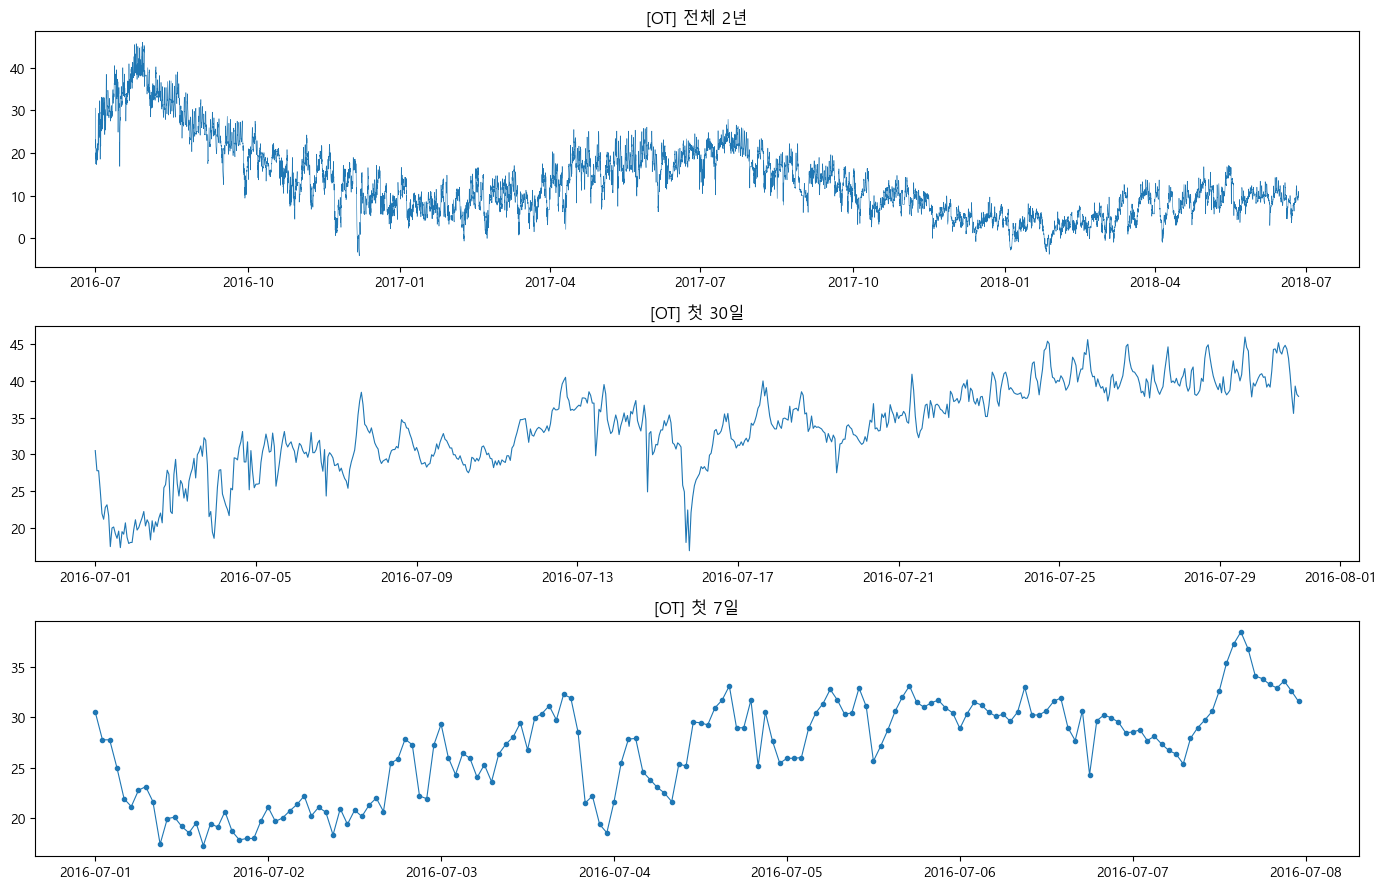

In [7]:
# vs code 환경상 한글 깨짐 방지
plt.rcParams['font.family'] = 'malgun gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(y.index, y.values, lw=0.4);                      axes[0].set_title(f"[{TARGET}] 전체 2년")
axes[1].plot(y.index[:24*30], y.values[:24*30], lw=0.8);      axes[1].set_title(f"[{TARGET}] 첫 30일")
axes[2].plot(y.index[:24*7], y.values[:24*7], marker=".", lw=0.8); axes[2].set_title(f"[{TARGET}] 첫 7일")
plt.tight_layout(); plt.show()

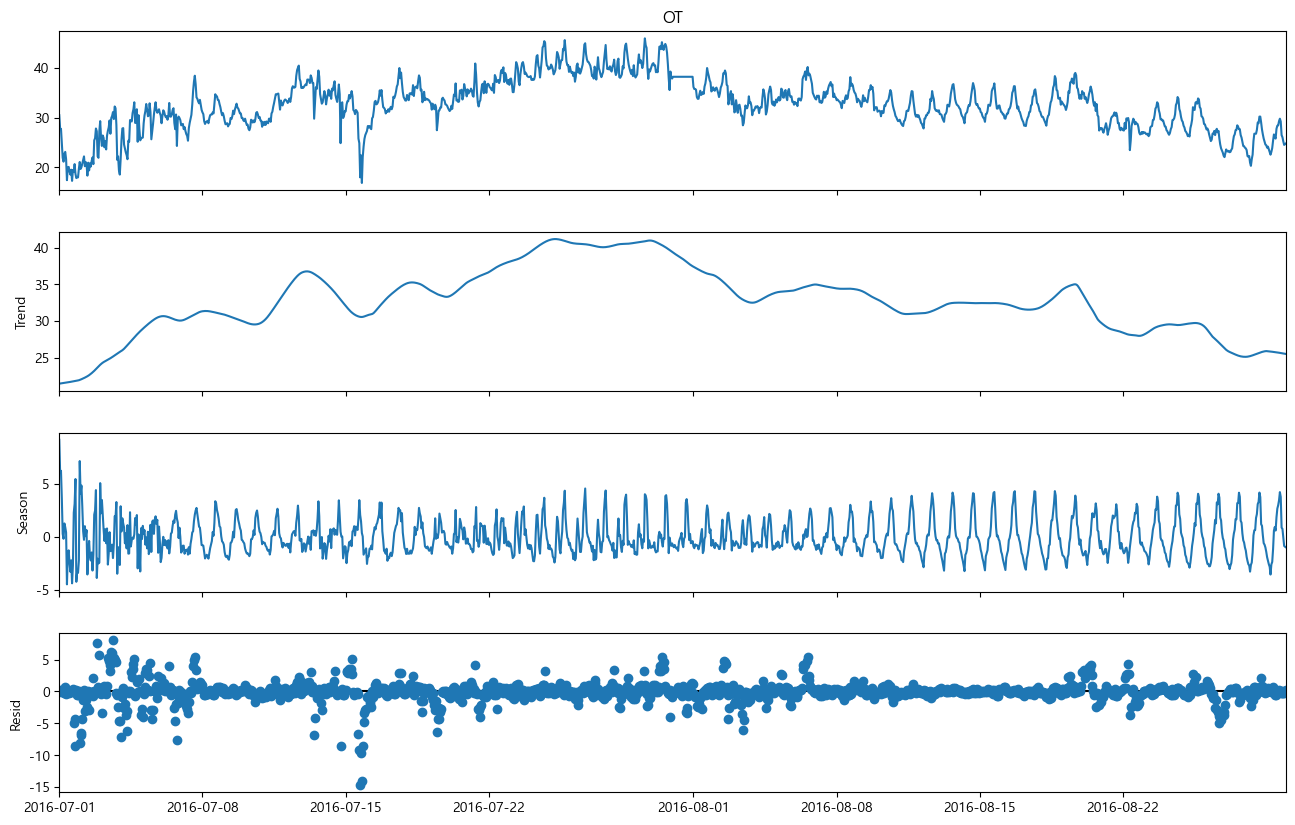

In [8]:
# 구성요소를 눈으로 분리해 봅니다.
# TODO: 이 데이터는 '시간 단위'입니다. 하루 주기를 잡으려면 period에 무엇을 넣어야 할까요?
PERIOD = 24 # 하루는 24시간

fig = STL(y.iloc[:24*60], period=PERIOD, robust=True).fit().plot()
fig.set_size_inches(14, 9); plt.show()

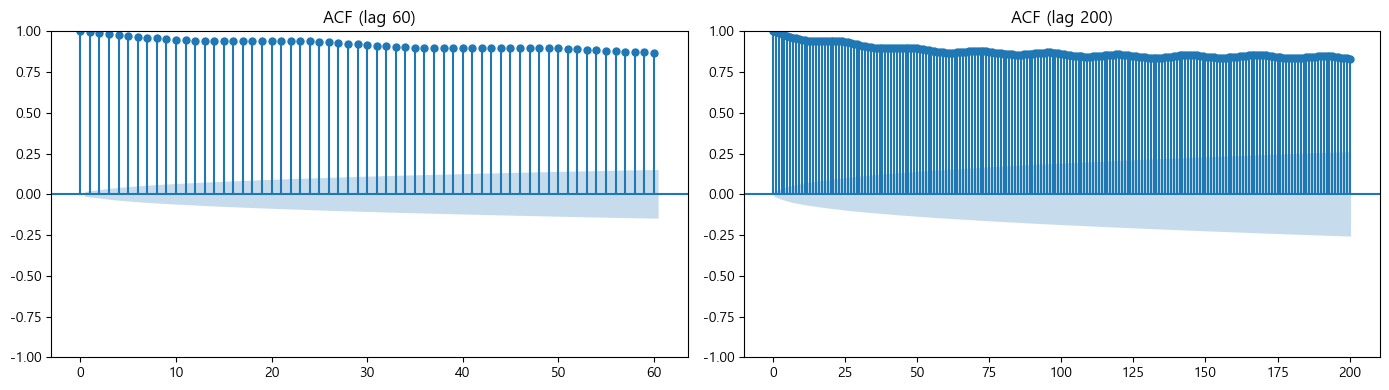

  ACF(lag=  1) = 0.994
  ACF(lag= 24) = 0.940
  ACF(lag= 48) = 0.900
  ACF(lag=168) = 0.856


In [9]:
# 자기상관성 확인 : 며칠 전 값이 현재와 얼마나 닮아 있는가
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y.dropna(), lags=60,  ax=axes[0]); axes[0].set_title("ACF (lag 60)")
plot_acf(y.dropna(), lags=200, ax=axes[1]); axes[1].set_title("ACF (lag 200)")
plt.tight_layout(); plt.show()

def acf_at(s, lag):
    # ACF(k) = 시차 k만큼 떨어진 값들의 공분산 / 전체 분산
    x = np.asarray(s.dropna(), float)
    x = x - x.mean()                      # 평균을 빼서 편차로 변환

    # TODO: ACF 정의를 떠올려 분자(공분산 부분)를 완성하세요.
    #          x[lag:]는 t=lag+1..N 시점, x[:-lag]는 t=1..N-lag 시점입니다.
    numerator = (x[:-lag]*x[lag:]).sum()
    # 공식 : sum_{t=1}^{N-k}{(y_{t}-bar{y})(y_{t+k}-bar{y})} / sum_{t=1}^{N}{(y_{t}-bar{y})^2}

    return numerator / (x * x).sum()      # 분모는 전체 분산

for lag in [1, 24, 48, 168]:
    print(f"  ACF(lag={lag:3d}) = {acf_at(y, lag):.3f}")

## 1-2. 정상성 진단 — ADF 검정

세션에서 배운 ADF 검정을 그대로 적용합니다.

| | 내용 |
|---|---|
| 귀무가설 | 단위근이 존재한다 → **비정상 시계열** |
| 대립가설 | 단위근이 존재하지 않는다 → **정상 시계열** |
| p-value < 0.05 | 귀무가설 기각 → **정상 시계열** |
| p-value ≥ 0.05 | 귀무가설 채택 → **비정상 시계열** |

In [10]:
def adf_report(series, name):
    s = pd.Series(series).dropna()
    stat, p = adfuller(s)[0], adfuller(s)[1]

    # TODO: 세션에서 배운 ADF의 귀무가설을 떠올리며 부등호를 채우세요.
    verdict = "정상 시계열" if p < 0.05 else "비정상 시계열"

    print(f"[{name:16s}] ADF={stat:9.3f}  p={p:.4f}  ->  {verdict}")
    return p

adf_report(y, "원본")

[원본              ] ADF=   -3.488  p=0.0083  ->  정상 시계열


np.float64(0.008301649485463776)

> ### Q1.
> ADF 검정 결과 **원본 시계열이 "정상"** 으로 나왔을 것입니다.
> 그런데 1-1에서 그린 **ACF를 보면 lag 24, 48, 72마다 봉우리가 계속 반복**되고 있습니다.
>
> 1. "정상 시계열인데 자기상관이 강하게 남아 있다"는 것이 모순처럼 보입니다. 모순이 아닌 이유를 설명하세요.
>    (힌트: **자기상관성**과 **정상성**은 **서로 다른 특징**으로 소개되었습니다. 각각의 정의를 다시 확인해 보세요.)
<br>자기상관성은 시계열 자체가 과거의 데이터로부터 특정 lag만큼 떨어져서 영향을 받고 있음을 의미하고 정상성은 시간이 변화하더라도 평균,분산과 같은 시계열 고유의 특성이 일정하게 유지되는 성질을 의미한다. 
정상성을 띈다는 것은 앞선 정의에 따라 시간에 따라 평균과 분산이 일정하다는 것이며 이는 과거의 영향이 시간이 지남에 따라 유의미하게 감소한다고 볼 수 있어 적은 자기상관성, 즉 약하게 남아있어야한다고 문제처럼 생각하기 쉽지만 계수가 1에 가까운 자기회귀모델을 떠올려 보면 정상시계열이지만 자기 상관이 강하게 남아있는 형태의 대표적인 예이다. 계수가 0.95정도만 되는 y_{t} = 0.95*y_{t-1}+epsilon을 떠올리자 </br>

> 2. 만약 ADF 결과만 보고 **"정상이니까 아무 처리 없이 바로 모델에 넣자"** 고 결론 내렸다면, 어떤 문제가 생길까요? 
<br>제가 알기로 Lijung-Box test나 Durbin-Watson test를 부차적으로 가해서 이런 정상인데도 자기상관성이 강하지는 않은지를 추가 검정하는 형태로 예방하는 것으로 알고 있습니다. 
자기 상관성이 강하면 spurious regression, ML에서는 lazy prediction과 같은 현상이 발생하는 문제가 유발되고 단순히 말하자면 실제로는 아무런 관계없는 값들이더라도 모델 스스로가 의미있다고 해석하게 된다.</br>

## 1-3. 차분(Differencing)

세션에서 **차분은 연이은 관측값들의 차이를 계산하는 것**이고, **추세나 계절성을 제거·감소**시킨다고 배웠습니다.

- **1차 차분** : $Y_t = X_t - X_{t-1}$
- **계절 차분** : $Y_t = X_t - X_{t-m}$  ($m$ = 계절 주기)

In [11]:
y_diff1 = y.diff()          # 1차 차분

# TODO: 하루 주기를 제거하는 계절 차분을 만드세요. (힌트: .diff(?) )
y_seas  = y.diff(24)

print("=" * 60)
adf_report(y,       "원본")
adf_report(y_diff1, "1차 차분")
adf_report(y_seas,  "계절 차분(lag 24)")
print("=" * 60)

[원본              ] ADF=   -3.488  p=0.0083  ->  정상 시계열
[1차 차분           ] ADF=  -26.383  p=0.0000  ->  정상 시계열
[계절 차분(lag 24)   ] ADF=  -23.901  p=0.0000  ->  정상 시계열


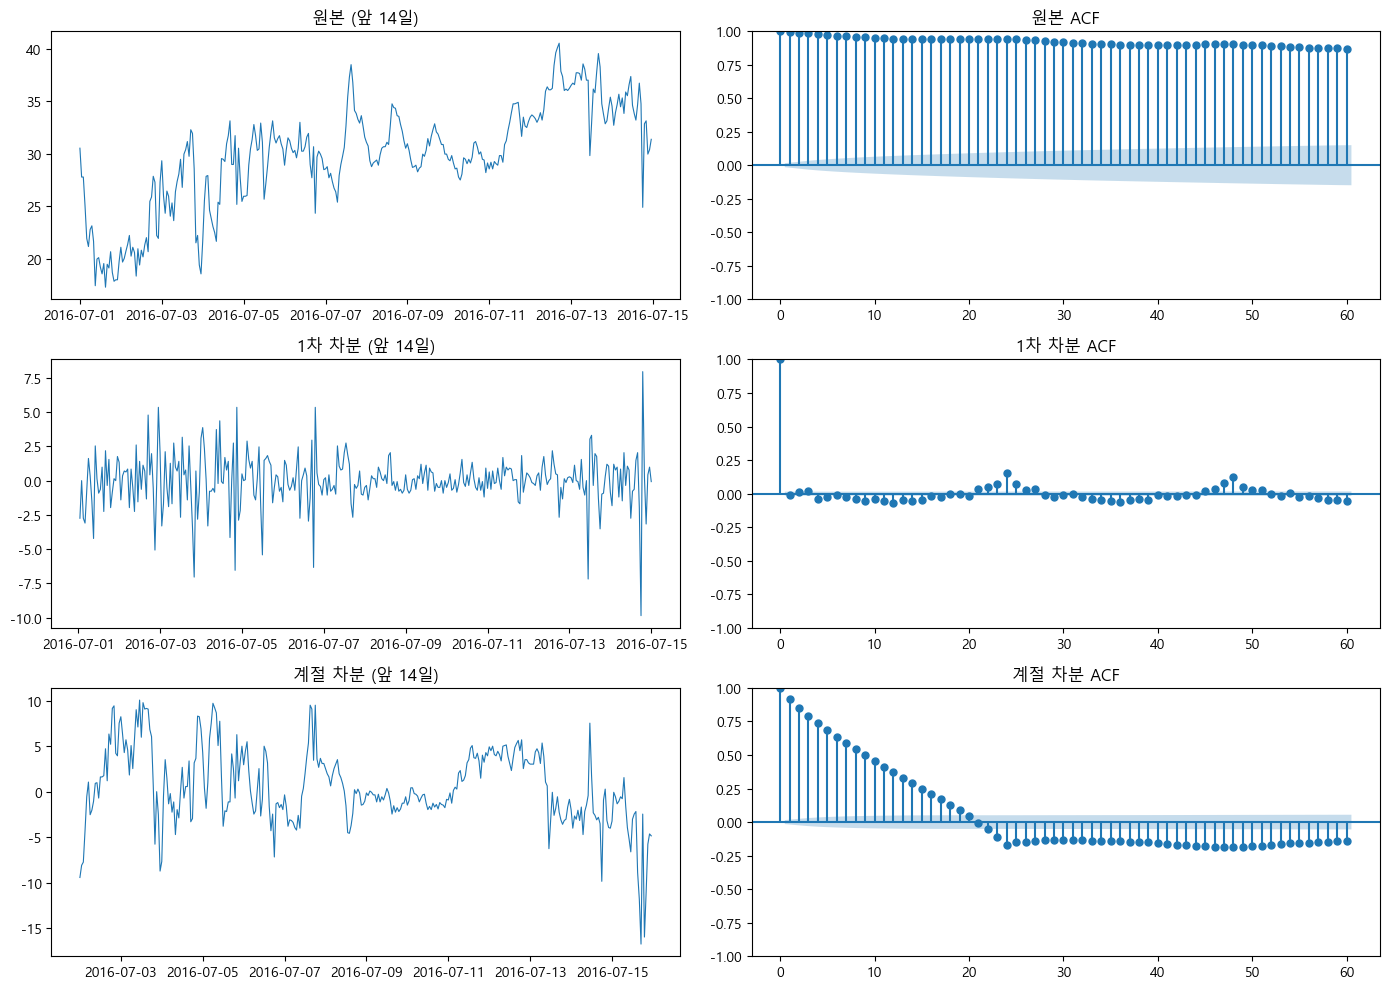

  원본           ACF(24) =   0.940
  1차 차분        ACF(24) =   0.154
  계절 차분        ACF(24) =  -0.169


In [12]:
# '차분 전 / 후' ACF를 비교합니다.
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for i, (s, name) in enumerate([(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]):
    s_ = s.dropna()
    axes[i, 0].plot(s_.index[:24*14], s_.values[:24*14], lw=0.8); axes[i, 0].set_title(f"{name} (앞 14일)")
    plot_acf(s_, lags=60, ax=axes[i, 1]);                          axes[i, 1].set_title(f"{name} ACF")
plt.tight_layout(); plt.show()

for s, name in [(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]:
    print(f"  {name:12s} ACF(24) = {acf_at(s, 24):7.3f}")

> ### Q2.
> 1. **계절 차분 후** ACF의 lag 24 값이 0 근처가 아니라 **음수로 크게** 나왔을 것입니다. 세션에서 차분의 목적은 "정상 시계열로 바꾸는 것"이었는데, 이 결과는 차분이 잘 된 것이라고 볼 수 있나요? 근거와 함께 쓰세요.
<br> 계절 차분 후 ADF 검정의 p-value가 0이므로 정상정 자체는 확보되었다고 볼 수 있지만 ACF(24)가 0.94에서 -0.168로 음의 자기상관 신호까지 만든 과하게 차분했다는 신호이다. 따라서 정상 시계열을 만드는데에는 성공했지만 적절한 차분이라고 보기에는 어렵다.

> 2. 위 결과를 종합해, 1-7에서 사용할 SARIMA의 **차분 차수 d 와 계절 차분 차수 D** 를 결정하고 근거를 서술하세요.
<br> 계절차분을 하고 나서 오히려 음의 상관관계가 생겼기 때문에 D=0으로 하는 것이 적합하며 차분 계수 d는 1차 차분을 통해 기존 ACF 값에서 대략 1/6정도의 감소를 이뤘기 때문에 1로 설정하는 것이 적합하다. 또한 p-value도 0으로 정상성까지 만족하기 때문에 d=1, D=0으로 하는 것이 가장 부합하다.

## 1-4. ACF / PACF로 차수 결정

세션에서 배운 판별표입니다.

| 확률과정 | ACF | PACF |
|---|---|---|
| **AR(p)** | 지수적으로 감소하거나 감쇠 사인파 형태 | **시차 p 이후 0으로 절단** |
| **MA(q)** | **시차 q 이후 0으로 절단** | 지수적으로 감소하거나 감쇠 사인파 형태 |
| **ARMA(p,q)** | 절단 없이 감소 | 절단 없이 감소 |

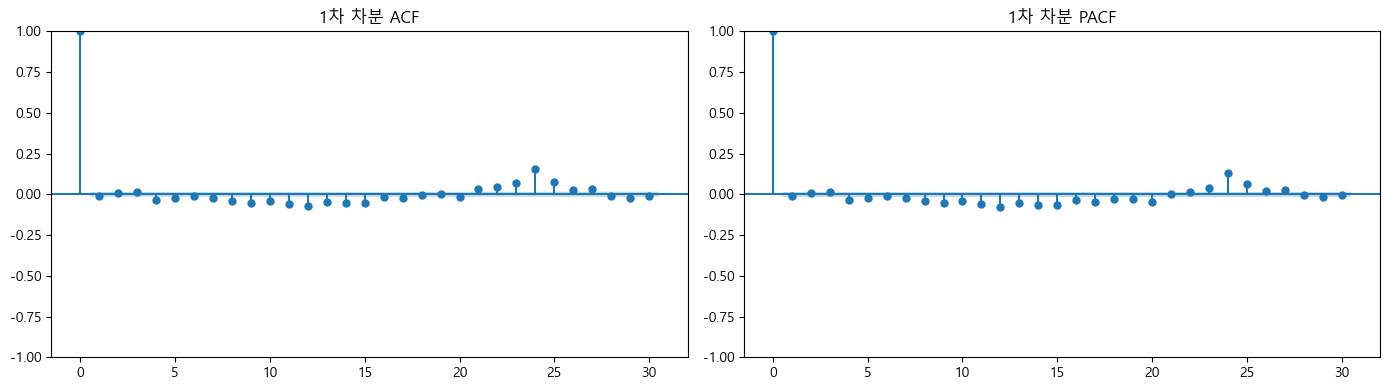

In [13]:
s_ = y_diff1.dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s_,  lags=30, ax=axes[0]); axes[0].set_title("1차 차분 ACF")
plot_pacf(s_, lags=30, ax=axes[1]); axes[1].set_title("1차 차분 PACF")
plt.tight_layout(); plt.show()

In [14]:
# TODO: Q2의 판단 결과와 위 ACF/PACF 그림을 반영하세요.
# 그래프 상 1차 차분의 ACF, PACF모두 다 1 근방에서 0에 가까운 값을 띄고 있어
# 뚜렷한 비계절 AR, MA 구조가 없다.
P_ORDER  = 0          # 비계절 AR 차수 p
D_ORDER  = 1          # 차분 차수 d
Q_ORDER  = 0          # 비계절 MA 차수 q
SEASONAL = (1, 0, 1, 24) # (P, D, Q, m)

print(f"SARIMA{(P_ORDER, D_ORDER, Q_ORDER)}{SEASONAL}")

SARIMA(0, 1, 0)(1, 0, 1, 24)


## 1-5. 평가 프로토콜 설계 — Time-Based Split

**여기가 이번 과제에서 가장 중요한 부분입니다.**
서로 다른 모델을 비교하려면 **완전히 동일한 조건**에서 평가해야 합니다.

세션에서 배운 **Time-Based Split** 을 사용합니다. 과거 데이터를 학습에, 이후 시점을 테스트에 쓰는 방식입니다.

| 항목 | 값 |
|---|---|
| Lookback (입력 길이 L) | 168시간 (= 1주) |
| Horizon (예측 길이 H) | 24시간 (= 1일) |
| 분할 | 시간순 train 70% / val 10% / test 20% |
| 평가 지점(origin) | test 구간에서 균등하게 30개 |

In [15]:
n = len(y)

# TODO: 시간순으로 70% / 80% 지점의 인덱스를 계산하세요.
i_train = int(n * 70 /100)
i_val   = int(n * 80 /100)

train, val, test = y[:i_train], y[i_train:i_val], y[i_val:]
L, H, M = 168, 24, 24        # lookback, horizon, 계절주기

for nm, s in [("train", train), ("val", val), ("test", test)]:
    print(f"{nm:6s} {len(s):6d}  ({s.index.min().date()} ~ {s.index.max().date()})")

train   12194  (2016-07-01 ~ 2017-11-21)
val      1742  (2017-11-21 ~ 2018-02-01)
test     3484  (2018-02-01 ~ 2018-06-26)


In [16]:
# 모든 모델이 공유할 평가 지점(origin) 30개
N_ORIGIN = 30

# TODO: origin끼리 예측 구간(H시간)이 겹치지 않게 하려면 간격을 얼마로 둬야 할까요?
cand    = np.arange(i_val, n - H, H)
origins = cand[np.linspace(0, len(cand) - 1, N_ORIGIN).astype(int)]
Y_TRUE  = np.stack([y.values[t:t + H] for t in origins])   # (30, 24) 정답

print("origin 개수:", len(origins), "| 정답 행렬:", Y_TRUE.shape)
print("첫 origin :", y.index[origins[0]], "/ 끝 origin :", y.index[origins[-1]])

origin 개수: 30 | 정답 행렬: (30, 24)
첫 origin : 2018-02-01 16:00:00 / 끝 origin : 2018-06-25 16:00:00


### 평가 지표

세션에서 다룬 **MAE / RMSE / MAPE** 세 가지를 사용합니다.

| 지표 | 정의 |
|---|---|
| MAE | 오차의 절대값 평균 |
| RMSE | 오차 제곱 평균의 제곱근 |
| MAPE | 오차 비율의 평균 (%) |

In [17]:
def score(name, pred):
    e    = Y_TRUE - pred
    mae  = np.mean(np.abs(e))
 
    # TODO: 세션의 정의를 보고 RMSE를 완성하세요.
    rmse = np.sqrt(np.mean(np.square(e)))

    nz   = np.abs(Y_TRUE) > 1e-6                       # 0 나눗셈 방지
    mape = np.mean(np.abs(e[nz] / Y_TRUE[nz])) * 100
    return dict(model=name, MAE=mae, RMSE=rmse, MAPE=mape)

results = []
excluded = (1 - (np.abs(Y_TRUE) > 1e-6).mean()) * 100
print(f"MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = {excluded:.2f}%")
print(f"정답값 중 절대값 0.5 미만 비율          = {(np.abs(Y_TRUE) < 0.5).mean()*100:.2f}%")
print(f"정답값 중 음수 비율                     = {(Y_TRUE < 0).mean()*100:.2f}%   (최솟값 {Y_TRUE.min():.3f})")

MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = 0.69%
정답값 중 절대값 0.5 미만 비율          = 0.69%
정답값 중 음수 비율                     = 0.00%   (최솟값 0.000)


## 1-6. 베이스라인 만들기

> - **Naive** : "다음 24시간도 지금 값이랑 똑같을 것이다"
> - **Seasonal Naive** : "내일 09시 값 = 오늘 09시 값" (24시간 전 같은 시각을 그대로 복사)
>
> 이렇게 **아무 학습도 하지 않는 예측**을 먼저 만들어 두는 이유는, 나중에 나온 MAE 값이 좋은 건지 나쁜 건지 판단할 **기준선**이 필요하기 때문입니다.

In [18]:
pred_naive  = np.stack([np.repeat(y.values[t - 1], H) for t in origins])

# TODO: Seasonal Naive를 구현하세요. 24시간 전 같은 시각부터 H시간을 그대로 가져옵니다.
pred_snaive = np.stack([y.values[t - 24 : t - 24 + H] for t in origins])

results.append(score("Naive",         pred_naive))
results.append(score("SeasonalNaive", pred_snaive))
pd.DataFrame(results).set_index("model").round(4)

,MAE,RMSE,MAPE
model,,,
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762


> ### Q3.
> 1. `Naive` 와 `SeasonalNaive` 의 성능 차이로부터 이 데이터의 어떤 성질을 알 수 있나요?
>    단, 1-1의 ACF 값을 다시 보면 **ACF(1)이 ACF(24)보다 큽니다.** "직전 값이 가장 닮았다"는 뜻인데 왜 `Naive`가 졌을까요?
>    (힌트: 이 과제는 1시간 뒤가 아니라 **24시간치를 한 번에** 예측합니다. `Naive`는 24시간 동안 무슨 값을 내놓나요?)
<br><br>  아무리 봐도 Naive가 지지 않고 이겼다. Naive의 MAE가 1.4107, SeasonalNaive는 1.8388로 Error의 크기가 더 작기 때문이다. 이는 시계열 데이터 자체가 직전 수준을 유지하는 단기 지속성을 더 크게 띄고 있음을 의미한다. 즉, 하루 주기의 반복성을 띄기보다 직전값의 단기 지속성을 더 강하게 띄고 있는 시계열 데이터라고 할 수 있다. 이는 ACF(1)과 ACF(24)간의 비교를 통해서도 유추해볼 수 있는데 전자가 0.994의 값, 후자가 0.940의 값을 띔과 같이 본다면 이 추론에 힘을 실을 수 있다. 다만 이것만으로는 24시간 전체 예측 성능이 항상 우수하다고 보기엔 힘들다.

> 2. 앞으로 만들 SARIMA / LSTM / DLinear 가 **최소한 어떤 수치를 넘어야** 의미 있는 모델일까요? 구체적인 숫자로 답하세요.
> *(이 질문의 답은 1-10에서 모델 성능을 해석할 때 기준선으로 계속 사용됩니다.)*
<br><br> 이후 구축할 모델들은 최소한 단순하게 만든 두 모델 중 성능이 더 좋은 Naive의 MAE, RMSE, MAPE보다 작은 지표를 띄고 있어야 한다. 적어도 하나 이상의 지표에서 해당 모델보다 우위를 점해야 단순히 직전값을 반복하는 예측보다 유의미하게 좋은 성능을 띄고 있다고 할 수 있다.

## 1-7. 모델 A — SARIMA

세션에서 배운 **Walk-Forward Validation** 을 그대로 적용합니다.
> 시간 순서를 유지하면서 예측 기준 시점을 순차적으로 이동시키며 **반복적으로 학습·예측·평가**를 수행

각 origin마다 **그 직전 1000시간만** 잘라 모델을 새로 적합하고 24시간을 예측합니다. (Rolling window 방식)

In [20]:

WINDOW = 1000
t0, preds = time.time(), []

for i, t in enumerate(origins):
    # TODO: origin t 직전 WINDOW 시간만 잘라내세요. (미래가 절대 포함되면 안 됩니다)
    hist = y.values[t-WINDOW : t]

    m = SARIMAX(hist, order=(P_ORDER, D_ORDER, Q_ORDER), seasonal_order=SEASONAL,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    # TODO: 앞으로 H시간을 예측하세요.
    preds.append(m.forecast(steps= H))

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(origins)}  ({time.time()-t0:.0f}s)")

pred_sarima = np.stack(preds)
results.append(score("SARIMA", pred_sarima))
print(f"\n총 소요 {time.time()-t0:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

  10/30  (5s)
  20/30  (14s)
  30/30  (21s)

총 소요 21초


,MAE,RMSE,MAPE
model,,,
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762
SARIMA,1.3393,1.8490,21.5928


## 1-8. 모델 B — LSTM

세션에서 RNN의 **기울기 소실** 문제와, 이를 완화하기 위한 **LSTM의 셀 상태 + 3개 게이트** 구조를 배웠습니다. 직접 학습시켜 봅니다.

### 스케일링

> ⚠️ **스케일러는 반드시 train 구간으로만 fit 해야 합니다.**
> 전체 데이터로 fit하면 train 시점에서는 알 수 없는 **미래의 평균·표준편차**가 흘러 들어갑니다.
> Walk-Forward에서 강조한 **Data Leakage** 가 여기서도 똑같이 발생합니다.

In [21]:
# TODO: 평균과 표준편차를 어느 구간에서 계산해야 할까요?
mu, sd = train.mean(), train.std()

ys = ((y - mu) / sd).values.astype("float32")
print(f"정규화 기준  mu={mu:.4f}, sd={sd:.4f}")

def make_windows(lo, hi, L_=None):
    """[lo, hi) 구간에서 (입력 L, 정답 H) 쌍을 슬라이딩으로 생성"""
    L_ = L_ or L
    X, Y = [], []
    for t in range(lo + L_, hi - H + 1):
        X.append(ys[t - L_ : t]); Y.append(ys[t : t + H])
    return torch.tensor(np.array(X)), torch.tensor(np.array(Y))

X_tr, Y_tr = make_windows(0, i_train)
X_va, Y_va = make_windows(i_train, i_val)
X_te       = torch.tensor(np.stack([ys[t - L : t] for t in origins]))

print("train:", X_tr.shape, "| val:", X_va.shape, "| test:", X_te.shape)

정규화 기준  mu=16.2947, sd=8.3488
train: torch.Size([12003, 168]) | val: torch.Size([1551, 168]) | test: torch.Size([30, 168])


In [23]:
# 학습 곡선 보는 법
#   - train / val이 나란히 감소 후 수평   -> 적절
#   - train은 계속 감소하는데 val이 반등  -> 과적합
#   - 둘 다 높은 채로 안 내려감           -> 과소적합 (epoch/lr 조정 필요)

def train_model(model, X_tr, Y_tr, X_va, Y_va, epochs=15, bs=64, lr=1e-3, tag=""):
    model = model.to(DEVICE)
    opt, lossf = torch.optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr), batch_size=bs, shuffle=True)

    history, best_val, best_state = {"train": [], "val": []}, float("inf"), None
    for ep in range(epochs):
        model.train(); total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            total += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            vl = lossf(model(X_va.to(DEVICE)), Y_va.to(DEVICE)).item()
        history["train"].append(total / len(X_tr)); history["val"].append(vl)

        # TODO: train loss가 아니라 val loss가 가장 낮았던 시점의 모델을 저장해야 합니다.
        #          어떤 조건일 때 이 epoch의 모델을 best_state로 저장해야 할까요?
        if vl <= best_val:
            best_val = vl; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if (ep + 1) % 5 == 0:
            print(f"  [{tag}] epoch {ep+1:3d}  train={history['train'][-1]:.5f}  val={vl:.5f}")
    model.load_state_dict(best_state)
    print(f"  [{tag}] best val loss = {best_val:.5f}  |  파라미터 {sum(p.numel() for p in model.parameters()):,d}")
    return model, history


def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(X.to(DEVICE)).cpu().numpy() * sd + mu


def plot_curve(hist, title):
    plt.figure(figsize=(7, 3.5))
    plt.plot(hist["train"], label="train", marker="o", ms=3)
    plt.plot(hist["val"],   label="val",   marker="s", ms=3)
    plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title(title)
    plt.legend(); plt.grid(alpha=.3); plt.show()

  [LSTM] epoch   5  train=0.10544  val=0.05750
  [LSTM] epoch  10  train=0.08901  val=0.10405
  [LSTM] epoch  15  train=0.08658  val=0.08986
  [LSTM] best val loss = 0.05750  |  파라미터 18,712


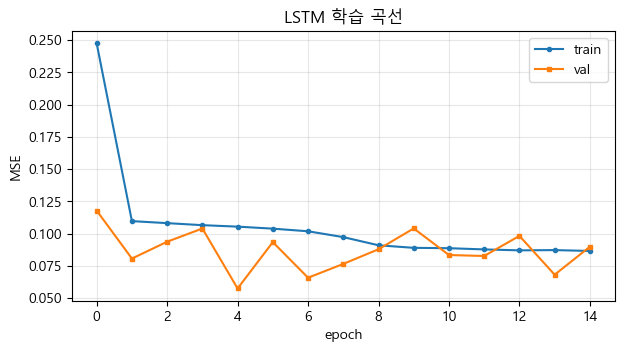

,MAE,RMSE,MAPE
model,,,
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762
SARIMA,1.3393,1.8490,21.5928
LSTM,1.1727,1.5978,19.9742


In [24]:
class LSTMForecast(nn.Module):
    def __init__(self, H, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc   = nn.Linear(hidden, H)

    def forward(self, x):                 # x: (B, L)
        out, _ = self.lstm(x.unsqueeze(-1))   # (B, L, hidden)
        # TODO: 168개 시점의 은닉 상태 중 예측에 사용할 것은 무엇일까요?
        #       (힌트: RNN 구조 그림에서 마지막 시점의 은닉 상태)
        return self.fc(out[:, -1])

torch.manual_seed(SEED)
t0 = time.time()
model_lstm, hist_lstm = train_model(LSTMForecast(H), X_tr, Y_tr, X_va, Y_va, tag="LSTM")
t_lstm = time.time() - t0
results.append(score("LSTM", predict(model_lstm, X_te)))
plot_curve(hist_lstm, "LSTM 학습 곡선")
pd.DataFrame(results).set_index("model").round(4)

## 1-9. 모델 C — LTSF-DLinear

세션에서 배운 DLinear의 3단계를 그대로 구현합니다.

```
(1) Moving Average로 데이터를 Trend(추세)와 Remainder(잔차) 성분으로 나눔
(2) 각 성분을 Linear 학습
(3) 두 레이어의 결과를 합하여 최종 예측값 생성          X̂ = H_s + H_t
```

  [DLinear] epoch   5  train=0.08355  val=0.03347
  [DLinear] epoch  10  train=0.08315  val=0.03601
  [DLinear] epoch  15  train=0.08288  val=0.04534
  [DLinear] best val loss = 0.03307  |  파라미터 8,112


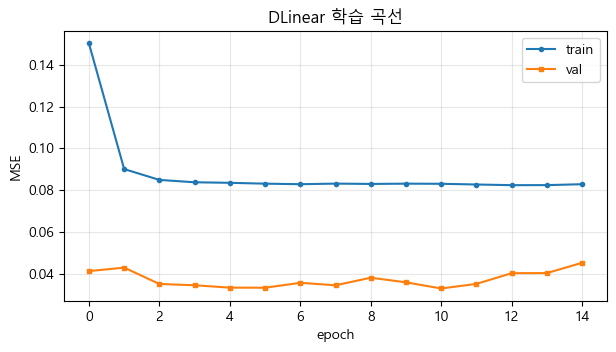

DLinear 학습 시간 7초


,MAE,RMSE,MAPE
model,,,
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762
SARIMA,1.3393,1.8490,21.5928
LSTM,1.1727,1.5978,19.9742
DLinear,1.2375,1.6099,20.7484


In [25]:
class DLinear(nn.Module):
    def __init__(self, L, H, kernel=25):   # kernel은 반드시 홀수 (짝수면 출력 길이가 1 늘어남)
        super().__init__()
        self.kernel = kernel
        self.lin_trend     = nn.Linear(L, H)   # 추세 성분용
        self.lin_remainder = nn.Linear(L, H)   # 잔차 성분용

    def series_decomp(self, x):
        """(1) 이동평균으로 Trend를 뽑고, 원본에서 빼서 Remainder를 얻습니다."""
        pad_len = self.kernel // 2
        pad   = torch.cat([x[:, :1].repeat(1, pad_len), x, x[:, -1:].repeat(1, pad_len)], dim=1)
        trend = nn.functional.avg_pool1d(pad.unsqueeze(1), self.kernel, stride=1).squeeze(1)

        # TODO: Remainder 성분은 어떻게 구하나요?
        remainder = x-trend
        return remainder, trend

    def forward(self, x):
        remainder, trend = self.series_decomp(x)
        # TODO: (3)단계입니다. 두 Linear의 출력을 어떻게 결합하나요?
        return self.lin_remainder(remainder) + self.lin_trend(trend)

torch.manual_seed(SEED)
t0 = time.time()
model_dl, hist_dl = train_model(DLinear(L, H), X_tr, Y_tr, X_va, Y_va, tag="DLinear")
t_dl = time.time() - t0
results.append(score("DLinear", predict(model_dl, X_te)))
plot_curve(hist_dl, "DLinear 학습 곡선")
print(f"DLinear 학습 시간 {t_dl:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

## 1-10. 성능 비교 및 해석

**완전히 동일한 30개 origin**에서 다섯 가지 예측을 비교합니다.

,MAE,RMSE,MAPE
model,,,
LSTM,1.1727,1.5978,19.9742
DLinear,1.2375,1.6099,20.7484
SARIMA,1.3393,1.8490,21.5928
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762


,MAE,개선율(%)
model,,
LSTM,1.1727,36.22
DLinear,1.2375,32.70
SARIMA,1.3393,27.16
Naive,1.4107,23.28
SeasonalNaive,1.8388,0.00


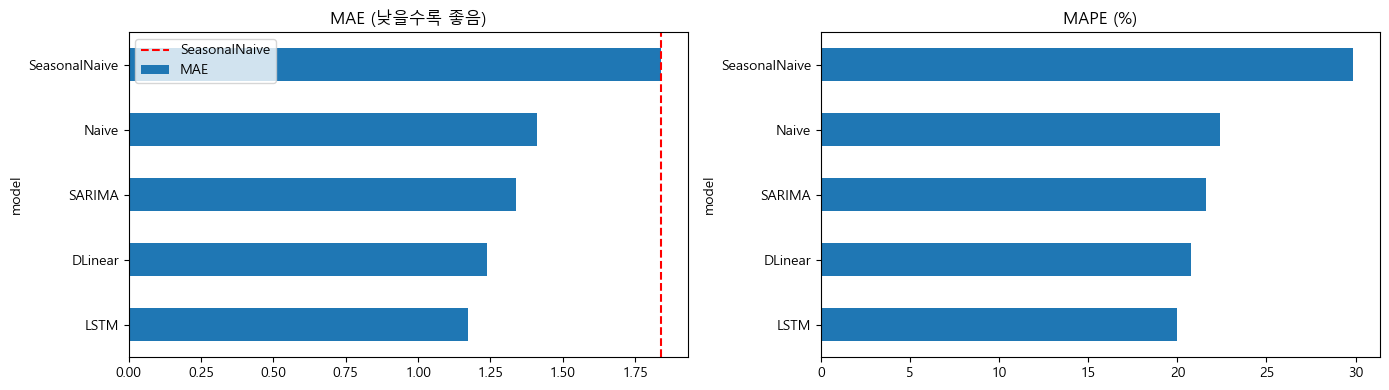

In [26]:
res = pd.DataFrame(results).set_index("model").sort_values("MAE").round(4)
display(res)

base = res.loc["SeasonalNaive", "MAE"]
res["개선율(%)"] = ((base - res["MAE"]) / base * 100).round(2)   # 베이스라인 대비
display(res[["MAE", "개선율(%)"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
res["MAE"].plot(kind="barh", ax=axes[0], title="MAE (낮을수록 좋음)")
axes[0].axvline(base, color="red", ls="--", label="SeasonalNaive"); axes[0].legend()
res["MAPE"].plot(kind="barh", ax=axes[1], title="MAPE (%)")
plt.tight_layout(); plt.show()

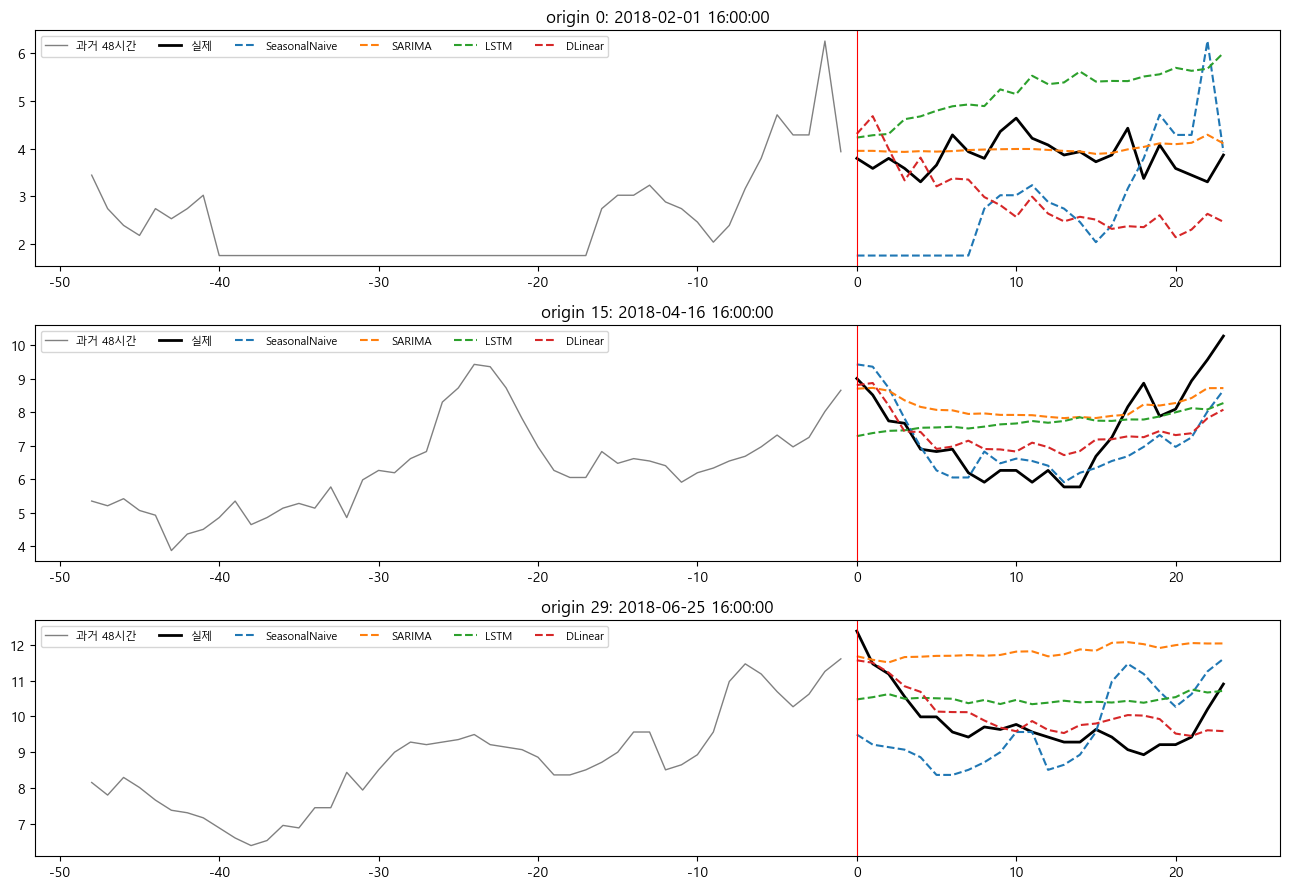

In [27]:
pred_dl, pred_lstm = predict(model_dl, X_te), predict(model_lstm, X_te)

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, k in zip(axes, [0, len(origins)//2, len(origins)-1]):
    t = origins[k]
    ax.plot(range(-48, 0), y.values[t-48:t], color="gray", lw=1, label="과거 48시간")
    ax.plot(range(H), Y_TRUE[k],      "k-", lw=2, label="실제")
    ax.plot(range(H), pred_snaive[k], "--", label="SeasonalNaive")
    ax.plot(range(H), pred_sarima[k], "--", label="SARIMA")
    ax.plot(range(H), pred_lstm[k],   "--", label="LSTM")
    ax.plot(range(H), pred_dl[k],     "--", label="DLinear")
    ax.axvline(0, color="red", lw=.8); ax.set_title(f"origin {k}: {y.index[t]}")
    ax.legend(fontsize=8, ncol=6)
plt.tight_layout(); plt.show()

> ### Q4. 왜 이러한 결과가 나왔는가?
> 순위를 나열하지 말고, **데이터의 성질과 각 모델의 구조를 연결**해서 설명하세요.
<br><br> Naive와 Seasonal Naive는 앞에서 설명했기에 나머지 모델 위주로 설명하겠다.
<br> 분석 대상이 되는 데이터셋은 ACF(1) 이 0.994, ACF(24)가 0.940, ACF(168)이 0.856으로 시간이 지나더라도 자기상관성이 눈에 띄게 감소하지 않는 시계열이다. 하루주기의 상관관계도 존재하지만 ACF(1)이 24보다 높고 seasonal 차분 후에는 ACF(24)가 음으로 나타났다. 따라서 정확히 24시간 전의 패턴이 반복된다고 하기 보다는 최근 수준과 비슷하도록 완만한 변화가 지속되는 성질을 띄고 있다고 할 수 있다. 
<br> SARIMA는 SARIMA(0,1,0)(1,0,1,24) 구조로 최근 변화와 24시간 시차의 선형적인 관계를 함께 반영했다. 그 결과 MAE가 Naive보다 5.06% 향상되었음을 알 수 있었다. 다만 과거 1000시간에서 추정한 고정된 선형적인 관계를 사용하고 24시간을 순차적으로 예측하기 때문에 시점에 따라 달라지는 변화나 급격한 전환을 표현하는데에는 한계가 있었다. 
<br> DLinear은 최근 168시간을 25시간 이동평균으로 구한 추세와 나머지 성분으로 분해한 뒤, 두 성분을 각각 선형층을 통해 학습에 사용한다. OT처럼 부드러운 수준의 변화와 강한 지속성을 가진 데이터에서 잘 맞는 구조이기 때문에 MAE는 1.2375를 기록했고 기존 SARIMA, Naive보다 개선시켰다. 이는 다시 말해서 OT의 예측 가능한 부분 중 상당 부분이 추세와 선형적인 변화로 설명된다는 것을 보여준다.
<br> LSTM은 최근 168시간의 순서 정보를 hidden 상태에 누적하고 비선형 관계를 학습할 수 있어 MAE는 1.1727로 가장 좋은 결과를 기록했다. 다만 Q5에 답하기에 앞서 예측 그래프를 보면 LSTM이 실제 추세를 잘 예측했다고 말하기 어렵다. MSE를 최소화하도록 학습했기 때문에 불확실한 구간에서는 실제 곡선의 세부적인 형태보다 매끄러운 예측을 내놓았고 이렇게 해서 평균 오차를 줄였다고 해석할 수 있다. 

> ### Q5. 세 모델의 성능 차이는 어디에서 발생했는가?
> 위 예측 곡선 그림을 근거로, **어떤 상황에서 어느 모델이 유리했는지** 구체적으로 짚으세요.
> (힌트: 평탄한 구간 / 급변 구간 / 예측 시점에서 먼 뒤쪽 시간대를 나눠서 보세요)
<br><br> 예측 곡선에서 모델별 차이는 평탄한 구간과 급변 구간에서 두드러졌다. origin 0처럼 실제값이 3.5 ~ 4.5 부근에서 유지되는 구간에서는 약 4를 예측한 SARIMA가 가장 정확했다. 반면 LSTM은 상승하고 DLinear는 하락하는 방향으로 예측해 시간이 지날수록 오차가 커졌다.
<br> origin 15와 29처럼 하락 후 반등하는 구간에서는 DLinear가 초반 하락을 비교적 잘 따라갔지만 후반 반등을 놓쳤고, SARIMA는 일정한 수준으로 평탄해져 급격한 변화를 반영하지 못했다. LSTM 역시 전환점과 변동 폭은 정확히 맞히지 못했지만 실제값의 중심 부근에서 매끄러운 값을 예측해 큰 오차를 줄였고, 특히 origin 29의 후반부에서는 최종 수준에 비교적 가까웠다.
<br> 따라서 평탄한 구간에서는 SARIMA, 완만하고 선형적인 변화에서는 DLinear가 유리했으며, LSTM은 곡선의 세부 형태보다 평균 수준을 안정적으로 예측해 전체 MAE를 낮췄다고 해석할 수 있다. 다만 세 모델 모두 급락 직후의 반등과 같은 급격한 전환에는 약했다. 또한 그래프는 30개 origin 중 3개만 보여주므로, 일부 구간에서 SARIMA나 DLinear가 더 정확해 보여도 전체 720개 예측값의 평균에서는 LSTM이 가장 낮은 오차를 기록할 수 있다.

> ### Q6. 예상과 다른 결과가 나왔다면 그 원인은 무엇인가?
> 1. 실험 전 예상과 실제 결과가 달랐던 지점을 하나 이상 쓰고 원인을 분석하세요.
<br> ACF(24)가 0.940으로 높아 SeasonalNaive가 Naive보다 좋을 것으로 예상했지만, 실제 MAE는 각각 1.8388과 1.4107로 SeasonalNaive가 더 나빴다. 이는 하루 전 패턴의 반복보다 최근 값이 유지되는 성질이 더 강했기 때문이다. 또한 LSTM이 가장 정확한 곡선을 예측할 것으로 예상했지만, 실제로는 급락과 반등을 놓치고 매끄러운 값을 출력했다. 그럼에도 전체 오차를 안정적으로 줄여 가장 낮은 MAE를 기록했다.

> 2. **MAPE 값이 유독 크게 나왔을 수 있습니다.** 1-5에서 출력한 통계(0에 가까운 값의 비율, **음수 비율**)와 연결해 원인을 설명하고, 세션에서 배운 세 지표 중 **이 데이터에서는 무엇을 주로 봐야 하는지** 근거와 함께 제시하세요.
>    (힌트: MAPE는 오차를 실제값으로 나눕니다. 실제값이 **음수**이면 그 결과를 "오차율"이라고 부를 수 있을까요?)
<br> 평가 대상에서 0에 가까운 값의 비율은 0.69%, 음수 비율은 0%였다. 정확히 0인 값은 MAPE 계산에서 제외됐으므로 이번 MAPE가 큰 원인을 음수 값 때문이라고 볼 수는 없다. 다만 실제값이 작은 양수이면 같은 절대오차도 큰 백분율로 계산되고,,0인 관측치는 평가에서 빠지므로 MAPE가 불안정할 수 있다. 전체 OT 원자료에는 음수도 존재하므로 이를 일반적인 '오차율'로 해석하기도 어렵다. 따라서 이 데이터에서는 실제 단위의 평균 오차를 직접 나타내는 MAE를 주 지표로 보고, 큰 오차에 민감한 RMSE를 보조 지표로 사용하는 것이 적절하다. MAPE는 참고용으로만 해석해야 한다.

---
# 2. 심화 과제

아래 2개 중 **최소 1개 이상** 수행하세요. 코드는 대부분 채워져 있으니 **결과 해석**에 집중하면 됩니다.

| | 주제 | 세션 | 확인하려는 것 |
|---|---|---|---|
| **심화 A** | Time-Based Split vs Walk-Forward 비교 | 06장 | 평가 구간을 어떻게 잡느냐로 결론이 바뀌는가 |
| **심화 B** | lookback 길이를 바꿔 가며 DLinear 재학습 | 05장 | 과거를 길게 볼수록 항상 좋아지는가 |

## 심화 A. 검증 전략 비교

같은 모델을 두 방식으로 평가하면 성능 추정치가 얼마나 달라지는지 확인합니다.

- **Time-Based Split** : test 구간의 **맨 앞 origin 1개**에서만 평가 (세션의 "단일 테스트 구간")
- **Walk-Forward** : 30개 origin 전체에서 평가

In [ ]:
p = predict(model_dl, X_te)
per_origin = np.abs(Y_TRUE - p).mean(axis=1)

# TODO: "Time-Based Split"은 test 구간에서 origin을 딱 1개(맨 처음)만 골라 평가하는 방식입니다.
#       per_origin 배열에서 그 origin의 결과는 어떻게 가져와야 할까요?
single_mae = per_origin[____]

print(f"Time-Based Split (origin 1개) MAE = {single_mae:.4f}")
print(f"Walk-Forward     (origin 30개) MAE = {per_origin.mean():.4f}")
print(f"origin별 MAE  최소 {per_origin.min():.4f} / 최대 {per_origin.max():.4f} / 표준편차 {per_origin.std():.4f}")

plt.figure(figsize=(11, 3.5))
plt.bar(range(len(per_origin)), per_origin)
plt.axhline(per_origin.mean(), color="red", ls="--", label=f"전체 평균 {per_origin.mean():.3f}")
plt.xlabel("origin index"); plt.ylabel("MAE"); plt.legend()
plt.title("origin별 MAE — 어느 구간을 고르느냐에 따라 결론이 달라진다")
plt.show()

## 심화 B. lookback 길이 실험

LTSF-Linear 계열은 **입력 구간(lookback)을 얼마나 주느냐**에 성능이 민감합니다. 직접 확인해 봅니다.

In [28]:
# TODO: 서로 다른 lookback 길이를 실험해 보세요. (예: 24, 96, 168, 336)
LOOKBACKS = [24, 96, 168, 336]

rows = []
for L_try in LOOKBACKS:
    Xa, Ya = make_windows(0, i_train, L_try)
    Xb, Yb = make_windows(i_train, i_val, L_try)
    Xc     = torch.tensor(np.stack([ys[t - L_try : t] for t in origins]))

    torch.manual_seed(SEED)
    m, _ = train_model(DLinear(L_try, H), Xa, Ya, Xb, Yb, epochs=15, tag=f"L={L_try}")
    s = score(f"L{L_try}", predict(m, Xc))
    rows.append({"lookback": L_try, "MAE": s["MAE"], "RMSE": s["RMSE"]})

pd.DataFrame(rows).set_index("lookback").round(4)

  [L=24] epoch   5  train=0.09874  val=0.03784
  [L=24] epoch  10  train=0.09702  val=0.03566
  [L=24] epoch  15  train=0.09696  val=0.03770
  [L=24] best val loss = 0.03566  |  파라미터 1,200
  [L=96] epoch   5  train=0.08725  val=0.03409
  [L=96] epoch  10  train=0.08654  val=0.03747
  [L=96] epoch  15  train=0.08644  val=0.03459
  [L=96] best val loss = 0.03346  |  파라미터 4,656
  [L=168] epoch   5  train=0.08355  val=0.03347
  [L=168] epoch  10  train=0.08315  val=0.03601
  [L=168] epoch  15  train=0.08288  val=0.04534
  [L=168] best val loss = 0.03307  |  파라미터 8,112
  [L=336] epoch   5  train=0.08250  val=0.05143
  [L=336] epoch  10  train=0.08200  val=0.03909
  [L=336] epoch  15  train=0.08107  val=0.05488
  [L=336] best val loss = 0.03441  |  파라미터 16,176


,MAE,RMSE
lookback,,
24,1.2570,1.7625
96,1.1940,1.5731
168,1.2375,1.6099
336,1.1755,1.5563


---
# 3. 생성형 AI 활용 방법

> **필수 작성 항목입니다.** 사용하지 않았다면 "사용하지 않음"이라고 명시하세요.

### 3-1. 활용 방법

| 항목 | 작성 |
|---|---|
| 사용한 도구 | chatgpt |
| 사용한 단계 | LSTM과 DLinear에서 직접적인 torch관련 문법이 이해안될때 사용했었습니다. |
| 사용 목적 | (예: 텐서 차원 오류 디버깅) |
| **AI 답변 중 그대로 쓰지 않고 수정한 부분** | 대부분 다른 코드 이해를 위해 사용했습니다|
| **AI 답변이 틀렸거나 검증이 필요했던 부분** | |

### 3-2. 대화 내역

```
일단 trend = nn.functional.avg_pool1d(pad.unsqueeze(1), self.kernel, stride=1).squeeze(1) 이거의 의미가 어떻게 이동평균이 되는지를 알려줘봐
7:07 PM
worked for 58s
해당 코드는 각 시점 주변의 25개 값을 평균 내서 trend를 만드는 이동평균입니다.
pad_len = self.kernel // 2   # kernel=25이면 12

pad = torch.cat([
    x[:, :1].repeat(1, pad_len),   # 첫 값을 왼쪽에 12번 복제
    x,
    x[:, -1:].repeat(1, pad_len)   # 마지막 값을 오른쪽에 12번 복제
], dim=1)

trend = nn.functional.avg_pool1d(
    pad.unsqueeze(1),   # (B, L) → (B, 1, L)
    self.kernel,        # 25개씩 평균
    stride=1            # 한 칸씩 이동
).squeeze(1)            # (B, 1, L) → (B, L)
kernel=25이므로 시점 t의 추세는 대략 다음과 같습니다.
\[
trend_t=\frac{x_{t-12}+\cdots+x_t+\cdots+x_{t+12}}{25}
\]즉, 주변 25시간의 평균을 내면서 한 시간씩 이동하므로 이동평균이 됩니다. 양 끝을 복제해서 패딩하는 이유는 이동평균을 구한 뒤에도 길이를 원래의 L=168로 유지하기 위해서입니다.
```

---
# 4. 회고

### 4-1. 가장 어려웠던 부분
>
### 4-2. 세션을 들을 때와 직접 해봤을 때 다르게 이해된 부분
>